# 3.1 Creating a neural network using the Sequential API

I0000 00:00:1791214640.624475  143651 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791214641.628413  143651 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9222 - loss: 0.2649 - val_accuracy: 0.9611 - val_loss: 0.1364
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9665 - loss: 0.1108 - val_accuracy: 0.9670 - val_loss: 0.1067
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9769 - loss: 0.0782 - val_accuracy: 0.9737 - val_loss: 0.0899
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9824 - loss: 0.0574 - val_accuracy: 0.9704 - val_loss: 0.1015
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9855 - loss: 0.0443 - val_accuracy: 0.9742 - val_loss: 0.0900
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9883 - loss: 0.0354 - val_accuracy: 0.9721 - val_loss: 0.1050
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9901 - loss: 0.0300 - val_accuracy: 0.9745 - val_loss: 0.0998
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9917 - loss: 0.0252 - 

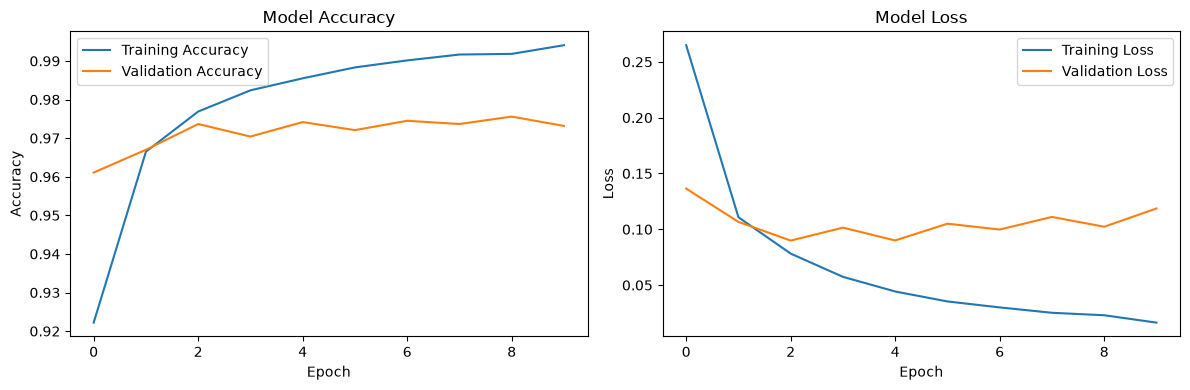

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


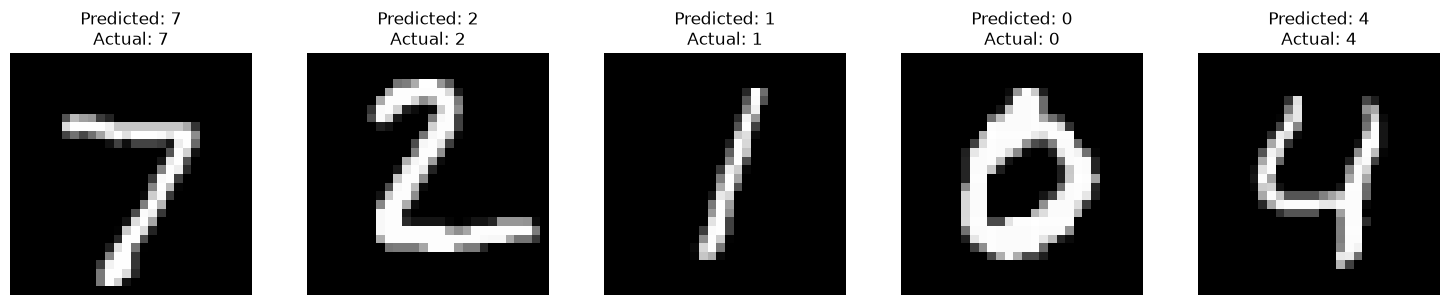

In [1]:
import os

# hide INFO/WARNING/ERROR від C++
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# Disable oneDNN messages
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0 # Normalize pixel values to [0, 1]
# Define a simple feedforward neural network using the Sequential API
model = Sequential(
    [
        # Input layer specifying the shape of the input images
        Input(shape=(28, 28)),
        # Flatten 28×28 images to a 1D vector of 784 elements
        Flatten(),
        # Hidden layer with 128 units and ReLU activation
        Dense(128, activation="relu"),
        # Second hidden layer with 64 units and ReLU activation
        Dense(64, activation="relu"),
        # Output layer with 10 units for classification (0-9 digits)
        Dense(10, activation="softmax"),
    ]
)
# Compile the model
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=32,
verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Make predictions on a few test images
predictions = model.predict(X_test[:5])
predicted_labels = tf.argmax(predictions, axis=1)

# Display the images and predictions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i], cmap='gray')
    ax.set_title(f"Predicted: {predicted_labels[i]}\nActual: {y_test[i]}")
    ax.axis('off')
    
plt.tight_layout()
plt.show()